In [45]:
import pandas as pd
import numpy as np
from datetime import datetime
import time
import csv

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, HDBSCAN
from scipy.optimize import curve_fit
import scipy.stats as stats


df =  pd.read_csv(r'C:\Users\qdr22hqu\QuakeMigrate\ruapehu\Ruapehu_Catalogue_1990_2023_West.csv')


In [46]:
# MoC
df_filtered = df[df['magnitude'] >= 1.58]

df = df_filtered

df

,publicid,eventtype,origintime,longitude,lat_er,latitude,lon_er,depth,depth_er,magnitude,mag_er,magnitudetype
0,95827,earthquake,1990-01-27T12:43:45.698Z,175.501040,0.010260,-39.196440,0.114810,18.624300,5.135800,2.672000,0.218000,ML
1,98577,earthquake,1990-02-15T21:18:41.807Z,175.543730,0.006730,-39.195730,0.015790,7.152200,0.826100,2.759000,0.107000,ML
2,105315,earthquake,1990-02-13T22:44:51.359Z,175.406880,0.004190,-39.105550,0.022490,6.809400,1.589200,2.542000,0.067000,ML
3,162453,earthquake,1990-10-07T07:37:28.724Z,175.329670,0.008510,-39.293850,0.016100,8.477000,1.839600,2.863000,0.178000,ML
4,165235,earthquake,1990-10-13T05:34:10.208Z,175.302170,0.020620,-39.287800,0.023460,15.855400,5.217500,1.780000,0.000000,ML
...,...,...,...,...,...,...,...,...,...,...,...,...
2790,2023p250803,earthquake,2023-04-03T19:07:53.556Z,175.420792,2.988072,-39.324551,3.353716,14.873635,6.719230,1.867758,0.000000,M
2791,2023p318526,earthquake,2023-04-28T20:31:06.086Z,175.396820,2.051327,-39.342892,2.576709,15.762478,2.952417,1.700276,0.179881,MLv
2792,2023p361499,earthquake,2023-05-14T18:06:42.383Z,175.327683,2.996339,-39.219910,3.934460,13.631891,5.884323,1.750446,0.224153,MLv
2793,2023p384816,earthquake,2023-05-23T09:10:32.352Z,175.345627,3.049917,-39.220001,3.695370,15.390323,5.518054,2.074356,0.184105,MLv


In [47]:
#RUN HDBSCAN geospatial clusters

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_norm = scaler.fit_transform(df[['latitude', 'longitude', 'depth']])

# Normalize depth to the same scale as latitude and longitude
df_norm[:, 2] = df_norm[:, 2] * scaler.scale_[0] / scaler.scale_[2]

# Add normalized columns to the original dataframe
df['n_latitude'] = df_norm[:, 0]
df['n_longitude'] = df_norm[:, 1]
df['n_depth'] = df_norm[:, 2]

X = df[['n_latitude', 'n_longitude', 'n_depth']].values



import hdbscan
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import time

min_samples = 32

# Run clusterer
start_time = time.time()
clusterer = hdbscan.HDBSCAN(min_cluster_size=min_samples, gen_min_span_tree=True)
df['cluster_hdbscan'] = clusterer.fit_predict(X)
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time: {elapsed_time} seconds")

Elapsed time: 0.10199952125549316 seconds


In [48]:
# Import the data - After Mc filter

print(df.columns)

# Convert 'origintime' column to datetime if not already in datetime format
df['origintimedate'] = pd.to_datetime(df['origintime'])

# Set 'origintime' as the DataFrame's index
df.set_index('origintimedate', inplace=True)

# Functions specific to Ruapehu


def convert_to_moment(magnitude):
    return (magnitude - 0.73) / 0.88

# Function to calculate seismic moment (M₀) from moment magnitude (Mw)


def calculate_seismic_moment(Mw):
    return 10**((2/3) * (Mw + 6.0))

Index(['publicid', 'eventtype', 'origintime', 'longitude', 'lat_er',
       'latitude', 'lon_er', 'depth', 'depth_er', 'magnitude', 'mag_er',
       'magnitudetype', 'n_latitude', 'n_longitude', 'n_depth',
       'cluster_hdbscan'],
      dtype='object')


In [49]:
# Convert richter to moment
# Calculate seismic moment for each row and create a new column 'Seismic_Moment'

df['Mag_Mw'] = df['magnitude'].apply(convert_to_moment)
df['Seismic_Moment'] = df['Mag_Mw'].apply(calculate_seismic_moment)

df

,publicid,eventtype,origintime,longitude,lat_er,latitude,lon_er,depth,depth_er,magnitude,mag_er,magnitudetype,n_latitude,n_longitude,n_depth,cluster_hdbscan,Mag_Mw,Seismic_Moment
origintimedate,,,,,,,,,,,,,,,,,,
1990-01-27 12:43:45.698000+00:00,95827,earthquake,1990-01-27T12:43:45.698Z,175.501040,0.010260,-39.196440,0.114810,18.624300,5.135800,2.672000,0.218000,ML,0.341566,1.612224,0.031835,-1,2.206818,295945.759301
1990-02-15 21:18:41.807000+00:00,98577,earthquake,1990-02-15T21:18:41.807Z,175.543730,0.006730,-39.195730,0.015790,7.152200,0.826100,2.759000,0.107000,ML,0.351054,2.253109,-0.036311,-1,2.305682,344446.052664
1990-02-13 22:44:51.359000+00:00,105315,earthquake,1990-02-13T22:44:51.359Z,175.406880,0.004190,-39.105550,0.022490,6.809400,1.589200,2.542000,0.067000,ML,1.556084,0.198644,-0.038348,-1,2.059091,235899.637070
1990-10-07 07:37:28.724000+00:00,162453,earthquake,1990-10-07T07:37:28.724Z,175.329670,0.008510,-39.293850,0.016100,8.477000,1.839600,2.863000,0.178000,ML,-0.960074,-0.960474,-0.028442,-1,2.423864,412961.049492
1990-10-13 05:34:10.208000+00:00,165235,earthquake,1990-10-13T05:34:10.208Z,175.302170,0.020620,-39.287800,0.023460,15.855400,5.217500,1.780000,0.000000,ML,-0.879231,-1.373318,0.015387,-1,1.193182,62438.799657
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-03 19:07:53.556000+00:00,2023p250803,earthquake,2023-04-03T19:07:53.556Z,175.420792,2.988072,-39.324551,3.353716,14.873635,6.719230,1.867758,0.000000,M,-1.370312,0.407492,0.009555,-1,1.292907,72767.562704
2023-04-28 20:31:06.086000+00:00,2023p318526,earthquake,2023-04-28T20:31:06.086Z,175.396820,2.051327,-39.342892,2.576709,15.762478,2.952417,1.700276,0.179881,MLv,-1.615394,0.047619,0.014835,-1,1.102586,54332.215097
2023-05-14 18:06:42.383000+00:00,2023p361499,earthquake,2023-05-14T18:06:42.383Z,175.327683,2.996339,-39.219910,3.934460,13.631891,5.884323,1.750446,0.224153,MLv,0.027953,-0.990311,0.002179,1,1.159597,59301.388078


In [50]:
# Parameters for DBSCAN

# Find the high level stats for the rolling window

# Define the rolling window size 
rolling_window = '30D'  # Select a number followed by 'D' for number of days

# Resample the data to calculate the number of events per day
events_per_day = df.resample('D')['publicid'].count()

# Use rolling to calculate the rolling average over the specified window size
rolling_average = events_per_day.rolling(rolling_window).sum()

# Calculate the overall average of the rolling averages
overall_average = rolling_average.mean()
min_average = rolling_average.min()
max_average = rolling_average.max()


print(
    f'Overall average of rolling averages over {rolling_window}: {overall_average:.2f}')
print(
    f'Minimum average of rolling averages over {rolling_window}: {min_average:.2f}')
print(
    f'Maximum average of rolling averages over {rolling_window}: {max_average:.2f}')

Overall average of rolling averages over 30D: 6.88
Minimum average of rolling averages over 30D: 0.00
Maximum average of rolling averages over 30D: 52.00


In [63]:
# Calculate the z-score for each rolling average
z_scores = (rolling_average - rolling_average.mean()) / rolling_average.std()

# Define the desired significance level (e.g., 0.05 for a 95% confidence interval)
significance_level = 0.01

# Calculate the threshold for the rolling_average
threshold = stats.norm.ppf(1 - (significance_level / 2)) * \
    rolling_average.std() + rolling_average.mean()

print(
    f'Rolling Average Threshold (based on {100 - significance_level * 100}% confidence interval): {threshold:.2f}')

Rolling Average Threshold (based on 99.0% confidence interval): 25.17


In [58]:
# DBSCAN parameters

eps_value_days = 30
#min_events = np.round(threshold, 0).astype(int)
min_events = round(threshold)
print(min_events)

16


In [59]:
df

,publicid,eventtype,origintime,longitude,lat_er,latitude,lon_er,depth,depth_er,magnitude,...,n_longitude,n_depth,cluster_hdbscan,Mag_Mw,Seismic_Moment,origintime_numeric,cluster_dbscan,cumulative_seismic_moment,anomaly,geometry
1066,2614739,earthquake,2006-08-23T07:08:42.778Z,175.51863,0.00557,-39.37346,0.00628,15.6914,0.9539,1.833,...,1.876294,0.014413,0,1.253409,68486.671642,13383.297717,0,5.260384e+06,0_0,POINT (175.51863 -39.37346)
1091,2617172,earthquake,2006-08-28T17:25:55.762Z,175.51733,0.00777,-39.38527,0.00707,15.9320,0.9223,1.771,...,1.856778,0.015842,0,1.182955,61466.199844,13388.726340,0,8.923675e+06,0_0,POINT (175.51733 -39.38527)
1092,2617201,earthquake,2006-08-28T19:07:32.668Z,175.50374,0.00812,-39.35811,0.01033,14.1292,0.8660,2.292,...,1.652758,0.005133,0,1.775000,152522.295654,13388.796906,0,9.076198e+06,0_0,POINT (175.50374 -39.35811)
1093,2617659,earthquake,2006-08-29T17:41:19.936Z,175.50638,0.00522,-39.36718,0.00717,13.1205,0.7000,2.020,...,1.692391,-0.000859,0,1.465909,94901.423604,13389.737036,0,9.171099e+06,0_0,POINT (175.50638 -39.36718)
1094,2617900,earthquake,2006-08-30T04:36:29.330Z,175.50847,0.00685,-39.37428,0.00665,16.4110,1.0291,1.621,...,1.723767,0.018687,0,1.012500,47315.125896,13390.192006,0,9.218414e+06,0_0,POINT (175.50847 -39.37428)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2673,1695963,earthquake,2001-02-22T10:24:33.876Z,175.40994,0.00596,-39.19314,0.01083,11.4400,0.9402,1.833,...,0.244582,-0.010841,5,1.253409,68486.671642,11375.433725,1,3.078917e+07,5_1,POINT (175.40994 -39.19314)
2674,1696546,earthquake,2001-02-24T06:08:35.592Z,175.38680,0.00708,-39.20679,0.01627,14.9409,1.0429,2.329,...,-0.102808,0.009955,5,1.817045,162691.040367,11377.255967,1,3.095186e+07,5_1,POINT (175.38680 -39.20679)
2675,1696561,earthquake,2001-02-24T07:41:45.078Z,175.40262,0.01084,-39.21276,0.02187,13.0574,1.2364,2.432,...,0.134690,-0.001234,5,1.934091,194712.547741,11377.320661,1,3.114657e+07,5_1,POINT (175.40262 -39.21276)
2677,1696592,earthquake,2001-02-24T10:35:46.472Z,175.40154,0.00843,-39.20071,0.01464,12.4930,1.0674,1.950,...,0.118477,-0.004586,5,1.386364,83992.870595,11377.441510,1,3.139354e+07,5_1,POINT (175.40154 -39.20071)


In [60]:
import time
import pandas as pd
from matplotlib.dates import date2num
from sklearn.cluster import DBSCAN

# Record the start time
start_time = time.time()

# Function to perform DBSCAN clustering
def dbscan_clustering(df, eps_value_days, min_events):
    # Convert 'origintime' to a numeric value for DBSCAN clustering
    df['origintime_numeric'] = date2num(pd.to_datetime(df['origintime']))
    
    # Prepare the data for DBSCAN using 'origintime_numeric'
    X = df['origintime_numeric'].values.reshape(-1, 1)
    
    # Apply DBSCAN clustering
    clusterer = DBSCAN(eps=eps_value_days, min_samples=min_events)
    cluster_labels = clusterer.fit_predict(X)
    
    # Add the DBSCAN cluster labels to the DataFrame
    df['cluster_dbscan'] = cluster_labels
    
    return df

# Function to calculate cumulative seismic moment
def calculate_cumulative_seismic_moment(df):
    df['cumulative_seismic_moment'] = df['Seismic_Moment'].cumsum()
    return df



# Initialize an empty list to store each cluster's DataFrame
cluster_dataframes = []

# Group by 'cluster_hdbscan' and apply DBSCAN clustering to each group
for cluster_num, cluster_df in df.groupby('cluster_hdbscan'):
    # Apply DBSCAN clustering
    clustered_df = dbscan_clustering(cluster_df, eps_value_days, min_events)
    
    # Calculate cumulative seismic moment for each cluster
    clustered_df = calculate_cumulative_seismic_moment(clustered_df)

    # Create the 'anomaly' column by concatenating 'cluster_hdbscan' and 'cluster_dbscan'
    clustered_df['anomaly'] = clustered_df['cluster_hdbscan'].astype(str) + "_" + clustered_df['cluster_dbscan'].astype(str)

    # Append the processed DataFrame to the list
    cluster_dataframes.append(clustered_df)
    

# Concatenate all cluster DataFrames into a single DataFrame
df_with_clusters = pd.concat(cluster_dataframes, ignore_index=True)



# Record the end time
end_time = time.time()

# Calculate the elapsed time
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time:.2f} seconds")




# Save the final DataFrame with DBSCAN results
output_file = r'C:\Users\qdr22hqu\QuakeMigrate\ruapehu\Ruapehu_Full_Catalogue_1990_2023_West_Mc_DBSCAN.csv'
df_with_clusters.to_csv(output_file, index=False)

# Display the final DataFrame (optional)
df_with_clusters


Elapsed time: 0.07 seconds


,publicid,eventtype,origintime,longitude,lat_er,latitude,lon_er,depth,depth_er,magnitude,...,n_longitude,n_depth,cluster_hdbscan,Mag_Mw,Seismic_Moment,origintime_numeric,cluster_dbscan,cumulative_seismic_moment,anomaly,geometry
0,2614739,earthquake,2006-08-23T07:08:42.778Z,175.51863,0.00557,-39.37346,0.00628,15.6914,0.9539,1.833,...,1.876294,0.014413,0,1.253409,68486.671642,13383.297717,0,6.848667e+04,0_0,POINT (175.51863 -39.37346)
1,2617172,earthquake,2006-08-28T17:25:55.762Z,175.51733,0.00777,-39.38527,0.00707,15.9320,0.9223,1.771,...,1.856778,0.015842,0,1.182955,61466.199844,13388.726340,0,1.299529e+05,0_0,POINT (175.51733 -39.38527)
2,2617201,earthquake,2006-08-28T19:07:32.668Z,175.50374,0.00812,-39.35811,0.01033,14.1292,0.8660,2.292,...,1.652758,0.005133,0,1.775000,152522.295654,13388.796906,0,2.824752e+05,0_0,POINT (175.50374 -39.35811)
3,2617659,earthquake,2006-08-29T17:41:19.936Z,175.50638,0.00522,-39.36718,0.00717,13.1205,0.7000,2.020,...,1.692391,-0.000859,0,1.465909,94901.423604,13389.737036,0,3.773766e+05,0_0,POINT (175.50638 -39.36718)
4,2617900,earthquake,2006-08-30T04:36:29.330Z,175.50847,0.00685,-39.37428,0.00665,16.4110,1.0291,1.621,...,1.723767,0.018687,0,1.012500,47315.125896,13390.192006,0,4.246917e+05,0_0,POINT (175.50847 -39.37428)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
384,1695963,earthquake,2001-02-22T10:24:33.876Z,175.40994,0.00596,-39.19314,0.01083,11.4400,0.9402,1.833,...,0.244582,-0.010841,5,1.253409,68486.671642,11375.433725,1,1.627234e+07,5_1,POINT (175.40994 -39.19314)
385,1696546,earthquake,2001-02-24T06:08:35.592Z,175.38680,0.00708,-39.20679,0.01627,14.9409,1.0429,2.329,...,-0.102808,0.009955,5,1.817045,162691.040367,11377.255967,1,1.643503e+07,5_1,POINT (175.38680 -39.20679)
386,1696561,earthquake,2001-02-24T07:41:45.078Z,175.40262,0.01084,-39.21276,0.02187,13.0574,1.2364,2.432,...,0.134690,-0.001234,5,1.934091,194712.547741,11377.320661,1,1.662974e+07,5_1,POINT (175.40262 -39.21276)
387,1696592,earthquake,2001-02-24T10:35:46.472Z,175.40154,0.00843,-39.20071,0.01464,12.4930,1.0674,1.950,...,0.118477,-0.004586,5,1.386364,83992.870595,11377.441510,1,1.671374e+07,5_1,POINT (175.40154 -39.20071)


In [61]:
df_filtered = df_with_clusters[df_with_clusters['cluster_dbscan'] != -1]

df_filtered = df_filtered[df_filtered['cluster_hdbscan'] != -1]

df = df_filtered

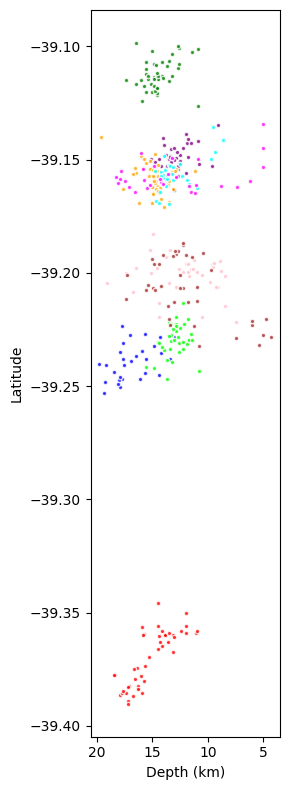

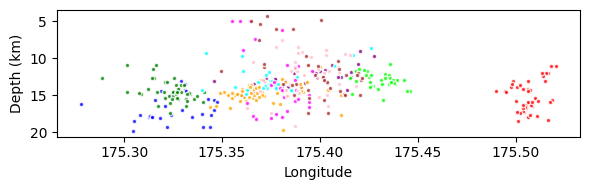

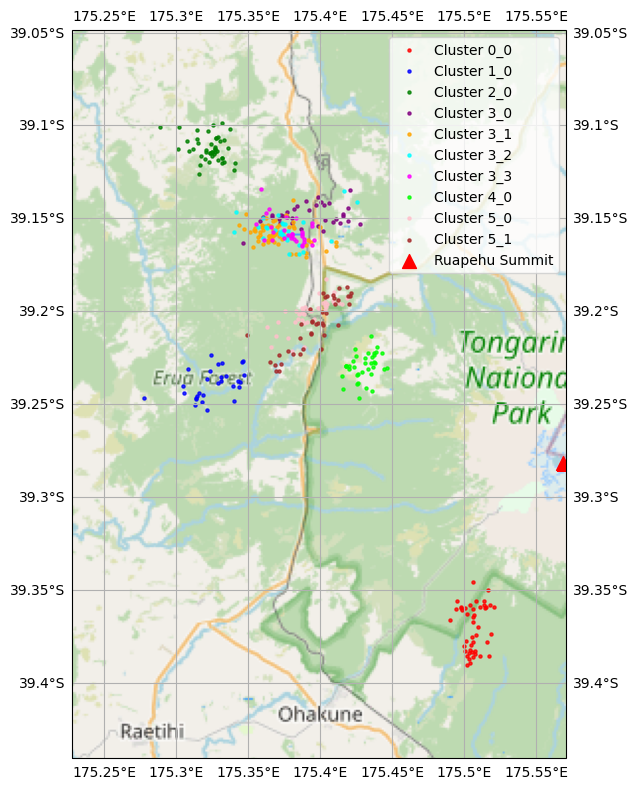

In [62]:

import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import cartopy.feature as cfeature

# Assuming df contains columns: 'latitude', 'longitude', 'depth', 'magnitude', 'cluster'
# Define custom colors for each cluster label
colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'lime', 'pink', 'brown']
color_dict = {-1: 'gray'}  # Assign gray color to noise points (outliers)
for i, label in enumerate(df['anomaly'].unique()):
    if label != -1:
        color_dict[label] = colors[i % len(colors)]

df = df.sort_values('anomaly')

# ---- Plot 1: Depth vs Latitude ----
fig1, ax1 = plt.subplots(figsize=(3, 8))
for label in df['anomaly'].unique():
    mask = df['anomaly'] == label
    cluster_color = color_dict.get(label, 'gray')
    
    # Plot Depth vs Latitude
    ax1.scatter(df.loc[mask, 'depth'], df.loc[mask, 'latitude'], 
                color=cluster_color, 
                edgecolor='white', 
                s=10 if label != '-1_-1' else 10, 
                alpha=0.8 if label != '-1_-1' else 0.3, 
                label=f'Cluster {label}' if label != -1 else 'Noise')

ax1.set_xlabel('Depth (km)')
ax1.set_ylabel('Latitude')
#ax1.set_title('Depth vs Latitude')
ax1.invert_xaxis()  # Invert the x-axis for depth
#ax1.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ---- Plot 2: Depth vs Longitude ----
fig2, ax2 = plt.subplots(figsize=(6, 2))
for label in df['anomaly'].unique():
    mask = df['anomaly'] == label
    cluster_color = color_dict.get(label, 'gray')
    
    # Plot Depth vs Longitude
    ax2.scatter(df.loc[mask, 'longitude'], df.loc[mask, 'depth'],
                color=cluster_color, 
                edgecolor='white', 
                s=10 if label != '-1_-1' else 10, 
                alpha=0.8 if label != '-1_-1' else 0.3, 
                label=f'Cluster {label}' if label != -1 else 'Noise')

ax2.set_xlabel('Longitude')
ax2.set_ylabel('Depth (km)')
#ax2.set_title('Depth vs Longitude')
ax2.invert_yaxis()  # Invert the x-axis for depth
#ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()



# Convert the DataFrame to a GeoDataFrame
df['geometry'] = gpd.points_from_xy(df['longitude'], df['latitude'])
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

# ---- Use OpenStreetMap Tiles for Background ----
osm_tiles = cimgt.OSM()  # Use OpenStreetMap tiles as background

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': osm_tiles.crs})

# Add OpenStreetMap tiles as the basemap
ax.add_image(osm_tiles, 10)  # The number 10 refers to the zoom level

# Plot the GeoDataFrame with cluster colors
for label in gdf['anomaly'].unique():
    mask = gdf['anomaly'] == label
    cluster_color = color_dict.get(label, 'gray')
    
    # Plot clusters with scatter points
    ax.scatter(gdf.loc[mask, 'longitude'], gdf.loc[mask, 'latitude'], 
               color=cluster_color, s=5 if label != -1 else 3, alpha=0.8, 
               transform=ccrs.PlateCarree(), label=f'Cluster {label}')

# Add the red triangle for the volcano at coordinates 39.2817° S, 175.5685° E
ax.scatter(175.5685, -39.2817, color='red', marker='^', s=100, label='Ruapehu Summit', transform=ccrs.PlateCarree())

# Set the extent based on your data
ax.set_extent([df['longitude'].min() - 0.05, df['longitude'].max() + 0.05, 
               df['latitude'].min() - 0.05, df['latitude'].max() + 0.05], crs=ccrs.PlateCarree())

# Add gridlines for better readability
ax.gridlines(draw_labels=True)

# Add a legend
plt.legend(loc='upper right')

# Show the plot
plt.tight_layout()
plt.show()
